Objetivo

Este notebook tem como objetivo transformar os dados analisados em visualizações claras e intuitivas, permitindo identificar padrões, tendências e insights relevantes sobre o comportamento dos clientes e sua experiência ao longo do tempo.

In [0]:
#1.Importação e preparação de dados

import matplotlib.pyplot as plt
import pandas as pd

#carregar tabela limpa
df = spark.table("amazon_reviews_clean")

#converter para pandas (para visualização)
pdf = df.toPandas()

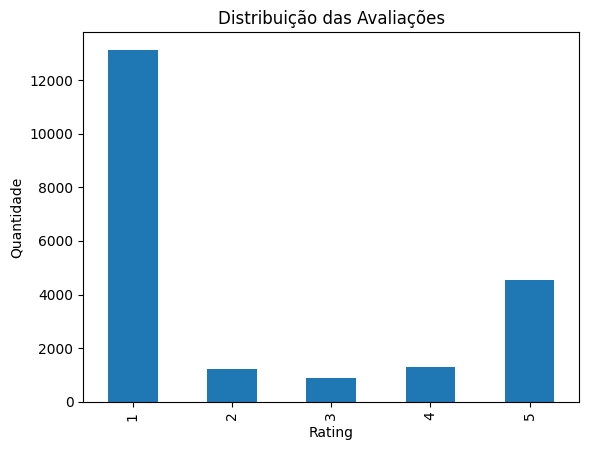

In [0]:
#2.Distribuição das avaliações (Rating)
#Gráfico 1 - Barras
pdf['rating_numeric'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribuição das Avaliações')
plt.xlabel("Rating")
plt.ylabel("Quantidade")
plt.show()

Observa-se uma forte concentração de avaliações com nota 1, indicando alto nível de insatisfação dos clientes.

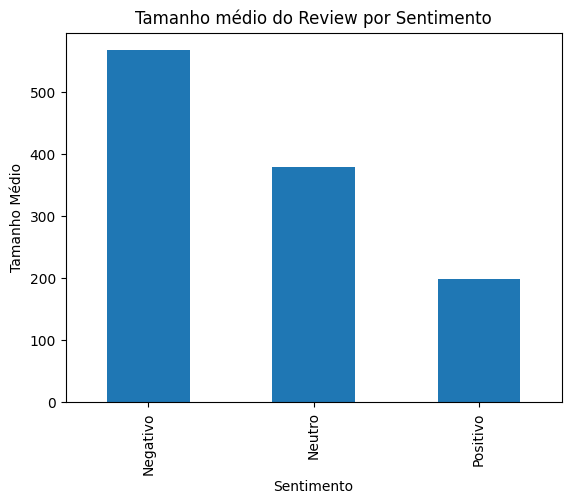

In [0]:
pdf.groupby('sentiment')['review_length'].mean().plot(kind='bar')

plt.title('Tamanho médio do Review por Sentimento')
plt.xlabel("Sentimento")
plt.ylabel('Tamanho Médio')
plt.show()

Interpretação

A predominância de sentimentos negativos reforça os resultados observados na distribuição de ratings.

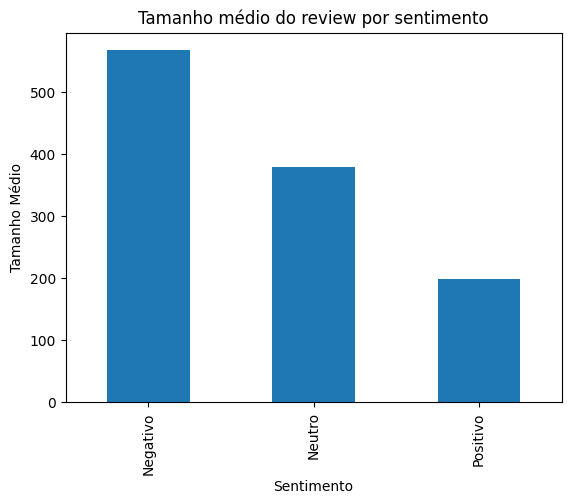

In [0]:
#4.Tamanho do Review por sentimento

pdf.groupby('sentiment')['review_length'].mean().plot(kind='bar')

plt.title("Tamanho médio do review por sentimento")
plt.xlabel('Sentimento')
plt.ylabel('Tamanho Médio')
plt.show()

 Interpretação

Reviews negativos são significativamente mais longos, indicando maior engajamento emocional dos clientes insatisfeitos.

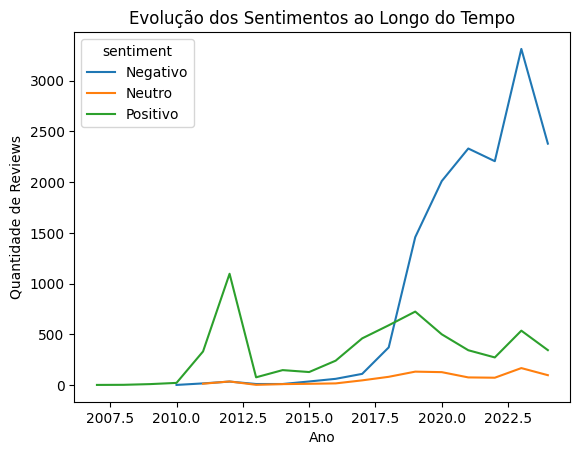

In [0]:
pdf['year'] = pd.to_datetime(pdf['review_date']).dt.year

sentiment_year = pdf.groupby(['year', 'sentiment']).size().unstack()

sentiment_year.plot()

plt.title("Evolução dos Sentimentos ao Longo do Tempo")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Reviews")
plt.show()

Interpretação

A partir de 2018, observa-se aumento significativo de avaliações negativas, indicando possível deterioração na experiência do cliente.

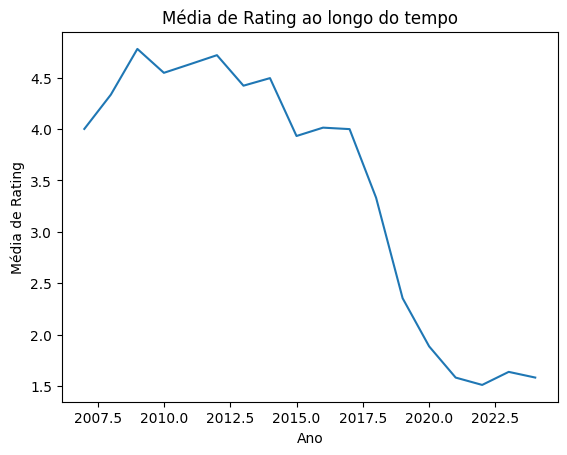

In [0]:
rating_year = pdf.groupby('year')['rating_numeric'].mean()

rating_year.plot()

plt.title("Média de Rating ao longo do tempo")
plt.xlabel("Ano")
plt.ylabel("Média de Rating")
plt.show()

Interpretação

A queda contínua da média de ratings ao longo dos anos reforça a tendência de aumento da insatisfação dos clientes.

 Interpretação

Palavras negativas aparecem com maior frequência, reforçando os insights sobre insatisfação dos clientes.

Conclusão das Visualizações

As visualizações confirmam os padrões identificados na análise exploratória, destacando a predominância de avaliações negativas e a queda progressiva na satisfação dos clientes ao longo do tempo.

A análise temporal evidencia uma mudança significativa no comportamento dos usuários a partir de 2018, com aumento consistente de sentimentos negativos e redução na média das avaliações.

Esses resultados reforçam a hipótese de deterioração na experiência do cliente, indicando a necessidade de investigação mais aprofundada das causas.